# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Imports e Definições Globais


In [1]:
import copy
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler, GoogleImageCrawler
import imagehash
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import shutil
import random
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import tempfile
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import to_pil_image
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from uuid import uuid4

In [2]:
# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


In [3]:
# Configuracao de variaveis e caminhos, para facilitar reexecucao incremental
RANDOM_SEED = 42
DATA_INSETOS = Path("data/insetos")
DATA_INSETOS_SPLIT_TRAIN = Path("data/insetos_split/train")
DATA_INSETOS_SPLIT_VAL = Path("data/insetos_split/val")
BAIDU_ROOT = Path("data/insetos-baidu")
CHECKPOINT_PATH = Path("checkpoints/insetos_resnet50_best.pt")
HISTORY_CSV_PATH = Path("checkpoints/insetos_training_history.csv")

# Dataset Bing usado como referencia: imagens Baidu duplicadas destes dirs sao descartadas
REFERENCE_DIRS = [DATA_INSETOS]

N_IMAGES_PER_CLASS = 100
DUPLICATE_THRESHOLD = 5


## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

Implementaremos uma logica para tratar adequadamente imagens repetidas e/ou execuções repetidas. Dessa forma reescrevemos a função de download original para ignorar imagens repetidas e considerar o total de imagens desejado e o total de imagens já existentes no diretorio de destino. Dessa forma, a curadoria das imagens fica facilitada, permitindo a seleção de imagens de forma iterativa e mais dinâmica.

Além dessa função, criamos uma função auxiliar fora do notebook para identificar pares de imagens repetidas dentro de um diretório, permitindo limpar qualquer conjunto de imagens previamente carregadas.

Dessa forma, adotamos uma abordagem iterativa para montar o dataset de abelhas e vespas. Fizemos um download inicial, inspecionamos o conteúdo dos diretorios limpando imagens inadequadas, depois executando novamente a rotina de download de imagens. Como a rotina identifica imagens repetidas, ignorando-as, bem como conta a quantidade de imagens pré-existentes no diretorio de destino, foi possivel executar várias vezes o processo até obter um conjunto de imagens adequado para ambas as classes.

Durante esse processo eliminamos aquelas imagens com mais de um inseto representado, aquelas claramente geradas por inteligencia artificial, bem como aquelas que deixaram dúvida quanto a classificação entre abelha e vespa. Em particular, em relação ao ultimo ponto, tivemos especial cuidado com aquelas imagens que o modelo classificou erroneamente o inseto. Analisamos manualmente as imagens posterior ao treino para decidir entre descartar a imagem ou incrementar a capacidade do modelo. Nosso objetivo aqui foi gerar um conjunto de treinamento adequado para que a tarefa de classificação ocorresse da melhor forma possível,

In [4]:
# tipos de imagens aceitas
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff"
}


def is_image_file(path: Path | str) -> bool:
    '''
    Verifica se o caminho fornecido é um arquivo de imagem.
    '''
    # Converte caminhos str (ou outros aceitos por Path) em pathlib.Path
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS

def list_images(folder: Path):
    '''
    Lista todos os arquivos de imagem em um diretório.
    '''
    if not folder.exists():
        return []

    return [
        p for p in folder.iterdir()
        if is_image_file(p)
    ]


def count_images(folder: Path) -> int:
    '''
    Conta o número de arquivos de imagem em um diretório.
    '''
    return len(list_images(folder))


def calculate_phash(path: Path):
    '''
    Calcula o hash phash de uma imagem. Auxilia na identificação de duplicatas.
    '''
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            return imagehash.phash(img)
    except Exception:
        return None


def load_existing_hashes(folder: Path):
    '''
    Carrega hashes de imagens existentes em um diretório.
    '''
    hashes = []

    for path in list_images(folder):
        h = calculate_phash(path)
        if h is not None:
            hashes.append((path, h))

    return hashes


def load_reference_hashes(reference_dirs):
    '''
    Carrega hashes de outros diretorios para evitar duplicados entre fontes
    '''
    hashes = []

    for ref_dir in reference_dirs or []:
        ref_path = Path(ref_dir)
        if not ref_path.exists():
            continue

        for path in ref_path.rglob("*"):
            if not is_image_file(path):
                continue

            h = calculate_phash(path)
            if h is not None:
                hashes.append((path, h))

    return hashes


def is_duplicate(candidate_hash, existing_hashes, threshold=5):
    '''
    Verifica se o hash perceptual de uma imagem candidata e suficientemente
    parecido com algum hash ja armazenado.

    Os hashes sao gerados por calculate_phash (imagehash.phash): um resumo
    compacto de 64 bits da aparencia visual da imagem. Dois objetos ImageHash
    podem ser subtraidos com o operador "-"; o resultado e a distancia de
    Hamming, ou seja, quantos bits diferem entre os dois hashes.

    Parametros
    ----------
    candidate_hash : imagehash.ImageHash
        Hash da imagem candidata.
    existing_hashes : list[tuple[Path, imagehash.ImageHash]]
        Pares (caminho, hash) das imagens ja aceitas no dataset ou em
        diretorios de referencia.
    threshold : int, default=5
        Limite maximo de distancia de Hamming para considerar duplicata.
        Valores menores exigem maior semelhanca; valores maiores toleram
        variacoes como redimensionamento, recompressao JPEG ou pequenos
        recortes.

    Retorna
    -------
    bool
        True se existir algum hash cuja distancia seja <= threshold;
        False caso contrario.

    Por que o threshold funciona
    ----------------------------
    Imagens identicas ou quase identicas produzem hashes muito proximos
    (distancia 0 ou baixa). Pequenas alteracoes visuais mudam poucos bits do
    hash, enquanto imagens diferentes tendem a ter distancias bem maiores.
    Com threshold=5, aceitamos no maximo 5 bits diferentes em 64 (~8%),
    o que captura duplicatas reais sem confundir fotos distintas da mesma
    classe. Threshold muito baixo deixa passar near-duplicates; muito alto
    pode descartar imagens legitimas diferentes.
    '''
    for _, existing_hash in existing_hashes:
        if candidate_hash - existing_hash <= threshold:
            return True

    return False


def next_image_name(folder: Path, label: str, extension: str) -> Path:
    '''
    Gera um nome de arquivo para uma nova imagem.
    '''
    while True:
        filename = f"{label}_{uuid4().hex[:12]}{extension.lower()}"
        target = folder / filename

        if not target.exists():
            return target


def download_images(
    crawler,
    keyword,
    root_dir,
    label=None,
    n_total=100,
    duplicate_threshold=5,
    batch_size=30,
    max_rounds=20,
    reference_dirs=None,
    crawl_max_idle_time=25,
):
    '''
    Baixa imagens de um buscador via icrawler ate atingir n_total no destino.

    A funcao e incremental: se root_dir ja contem imagens suficientes, nenhum
    download e feito. Caso contrario, executa rodadas de busca em diretorio
    temporario, filtra candidatos invalidos e duplicados (hash perceptual) e
    move apenas imagens aceitas para root_dir com nomes unicos.

    Parametros
    ----------
    crawler : BingImageCrawler | BaiduImageCrawler
        Instancia do crawler icrawler configurada com storage.
    keyword : str
        Termo de busca enviado ao buscador de imagens.
    root_dir : str | Path
        Diretorio de destino onde as imagens aceitas serao salvas.
    label : str, optional
        Prefixo dos arquivos gerados. Se None, usa o nome de root_dir.
    n_total : int, default=100
        Quantidade alvo de imagens validas e unicas em root_dir.
    duplicate_threshold : int, default=5
        Limite de distancia de Hamming para is_duplicate considerar repeticao.
    batch_size : int, default=30
        Tamanho minimo de candidatos solicitados por rodada. O valor efetivo
        e max(batch_size, remaining * 3) para compensar descartes.
    max_rounds : int, default=20
        Numero maximo de rodadas de busca antes de encerrar sem atingir n_total.
    reference_dirs : list[str | Path] | None, default=None
        Diretorios adicionais cujos hashes entram na comparacao, evitando
        duplicatas entre fontes ou pastas ja curadas.
    crawl_max_idle_time : int, default=25
        Tempo maximo de inatividade (segundos) repassado a crawler.crawl.

    Retorna
    -------
    None
        Imagens aceitas ficam em root_dir; progresso e estatisticas sao
        impressos via print.

    Raises
    ------
    ValueError
        Se crawler for GoogleImageCrawler (incompativel com icrawler atual).

    Notas
    -----
    Cada rodada: crawl em tmpdir -> phash de cada candidato -> descarta
    invalidos e duplicatas (incluindo referencias) -> move aceitos para
    root_dir. Interrompe ao atingir n_total, esgotar max_rounds ou quando
    uma rodada nao aceita nenhuma imagem nova (busca saturada).
    '''
    if isinstance(crawler, GoogleImageCrawler):
        raise ValueError(
            "GoogleImageCrawler não funciona com o icrawler atual. "
            "Use BaiduImageCrawler ou BingImageCrawler."
        )

    root_dir = Path(root_dir)
    root_dir.mkdir(parents=True, exist_ok=True)

    if label is None:
        label = root_dir.name

    current_total = count_images(root_dir)

    if current_total >= n_total:
        print(
            f"Pasta já possui {current_total} imagens. "
            f"Nenhum download necessário para alvo n_total={n_total}."
        )
        return

    existing_hashes = load_existing_hashes(root_dir)
    reference_hashes = load_reference_hashes(reference_dirs)
    existing_hashes.extend(reference_hashes)

    print(f"Imagens já existentes: {current_total}")
    print(f"Meta final: {n_total}")
    print(f"Novas imagens necessárias: {n_total - current_total}")
    print(f"Hashes carregados: {len(existing_hashes)} ({len(reference_hashes)} de referência)")

    rounds = 0

    while current_total < n_total and rounds < max_rounds:
        rounds += 1

        remaining = n_total - current_total

        # Baixa mais do que o restante porque algumas serao descartadas.
        current_batch_size = max(batch_size, remaining * 3)

        with tempfile.TemporaryDirectory() as tmpdir:
            tmpdir = Path(tmpdir)

            crawler.storage.root_dir = str(tmpdir)

            crawler.crawl(
                keyword=keyword,
                max_num=current_batch_size,
                max_idle_time=crawl_max_idle_time,
            )

            candidates = [
                p for p in tmpdir.iterdir()
                if is_image_file(p)
            ]

            accepted = 0
            discarded_duplicates = 0
            discarded_invalid = 0

            for candidate in candidates:
                if current_total >= n_total:
                    break

                candidate_hash = calculate_phash(candidate)

                if candidate_hash is None:
                    discarded_invalid += 1
                    continue

                if is_duplicate(
                    candidate_hash,
                    existing_hashes,
                    threshold=duplicate_threshold
                ):
                    discarded_duplicates += 1
                    continue

                extension = candidate.suffix.lower()

                if extension not in IMAGE_EXTENSIONS:
                    extension = ".jpg"

                target = next_image_name(root_dir, label, extension)

                shutil.move(str(candidate), str(target))

                existing_hashes.append((target, candidate_hash))
                current_total += 1
                accepted += 1

            print(
                f"Rodada {rounds}: "
                f"aceitas={accepted}, "
                f"duplicadas={discarded_duplicates}, "
                f"inválidas={discarded_invalid}, "
                f"total_final={current_total}/{n_total}"
            )

            if accepted == 0:
                print("Nenhuma imagem nova aceita nesta rodada. A busca pode estar saturada.")

    if current_total == n_total:
        print(f"Download completo. Pasta destino contém exatamente {n_total} imagens.")
    else:
        print(
            f"Encerrado com {current_total}/{n_total}. "
            f"Limite de rodadas atingido."
        )


def remove_duplicates_against_reference(target_root, reference_dirs, threshold=5):
    target_root = Path(target_root)
    reference_hashes = load_reference_hashes(reference_dirs)
    removed_total = 0

    if not target_root.exists():
        return removed_total

    for class_dir in sorted(target_root.iterdir()):
        if not class_dir.is_dir():
            continue

        removed_class = 0
        for image_path in list_images(class_dir):
            candidate_hash = calculate_phash(image_path)
            if candidate_hash is None:
                continue

            if is_duplicate(candidate_hash, reference_hashes, threshold=threshold):
                image_path.unlink()
                removed_class += 1

        removed_total += removed_class
        print(
            f"{class_dir.name}: removidas={removed_class}, "
            f"restantes={count_images(class_dir)}"
        )

    return removed_total

As funções a seguir permitem identificar cada macro-tarefa da atividade e determinar se ela já foi executada e salva no disco. Caso não tenha sido executada e completada, a tarefa é reiniciada. Caso tenha sido executada, carrega do disco local o resultado da tarefa. Dessa forma, o notebook permite sucessivas execuções sem necessariamente passar por todas as tarefas demoradas novamente: uma vez que a macro-tarefa foi concluida, os dado são carregados do disco e o fluxo de execução continua normalmente.

Dessa forma foi possivel executar a obtenção e curadoria de imagens de forma iterativa com multiplas execuções.

In [5]:

def split_already_exists(root_dir) -> bool:
    '''
    Verifica se o split treino/validacao ja foi gerado e esta utilizavel.

    Espera a estrutura {root_dir}_split/train e {root_dir}_split/val, com uma
    subpasta por classe presente em root_dir e pelo menos uma imagem em cada
    subpasta de treino e de validacao.

    Parametros
    ----------
    root_dir : str | Path
        Diretorio raiz do dataset bruto (ex.: data/insetos), com subpastas
        por classe.

    Retorna
    -------
    bool
        True se train/ e val/ existem e cada classe tem imagens em ambos;
        False caso contrario (split ausente, vazio ou incompleto).
    '''
    root_dir = Path(root_dir)
    split_root = Path(f"{root_dir}_split")
    train_dir = split_root / "train"
    val_dir = split_root / "val"

    if not train_dir.is_dir() or not val_dir.is_dir():
        return False

    class_dirs = [p for p in root_dir.iterdir() if p.is_dir()]
    if not class_dirs:
        return False

    for class_dir in class_dirs:
        if count_images(train_dir / class_dir.name) == 0:
            return False
        if count_images(val_dir / class_dir.name) == 0:
            return False

    return True

def build_insetos_model(num_classes, weights=None):
    '''
    Monta ResNet50 com backbone congelada e cabeca de classificacao compartilhada.

    Unico ponto do notebook onde a cabeca fc e definida. Usada no treino do zero
    (weights=ResNet50_Weights.DEFAULT) e no carregamento de checkpoint
    (weights=None, pesos vindos do state_dict via load_insetos_checkpoint).

    Parametros
    ----------
    num_classes : int
        Numero de classes de saida.
    weights : ResNet50_Weights | None, default=None
        Pesos iniciais da backbone. None quando os pesos serao carregados de
        checkpoint; DEFAULT (ImageNet) para transfer learning.

    Retorna
    -------
    torch.nn.Module
        ResNet50 com requires_grad=False na backbone e fc substituida.
    '''
    m = models.resnet50(weights=weights)
    for param in m.parameters():
        param.requires_grad = False

    in_features = m.fc.in_features
    # adicionamos uma camada linear com 256 neurônios, uma camada ReLU, uma camada Dropout com taxa de 30% e uma camada linear com num_classes neurônios
    # pois o resultado da rede inicial com apenas 1 camada linear não foi capaz de classificar a totalidade das imagens de treino/validação.
    m.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return m



def load_insetos_checkpoint(path, device):
    '''
    Carrega o modelo treinado a partir de um checkpoint.
    '''
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model = build_insetos_model(num_classes=checkpoint["num_classes"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model, checkpoint


def save_insetos_checkpoint(model, train_dataset, history_df, best_val_acc, path):
    '''
    Salva o modelo treinado em um checkpoint.
    '''
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "idx_to_class": {
            idx: name for name, idx in train_dataset.class_to_idx.items()
        },
        "architecture": "resnet50",
        "num_classes": len(train_dataset.class_to_idx),
        "image_size": train_dataset.image_size,
        "best_val_acc": float(best_val_acc),
        "history": history_df.to_dict(orient="list"),
    }

    torch.save(checkpoint, path)
    print(f"Modelo salvo em: {path.resolve()}")


A seguir executamos o download de imagens a partir dos termos de busca e classes definidos em ```search_terms```

In [6]:
search_terms = {
    # nome da classe: termo que sera usado na busca
    "abelha": "single real bee on nature",
    "vespa": "single real wasp in nature"
}

bing_image_crawler = BingImageCrawler(storage={"root_dir": "images"})
# bing_image_crawler = GoogleImageCrawler(storage={"root_dir": "images"}) # Google não funciona com o icrawler atual

for label, term in search_terms.items():
    download_images(
        bing_image_crawler,
        term,
        DATA_INSETOS / label,
        n_total=N_IMAGES_PER_CLASS,
    )

Pasta já possui 100 imagens. Nenhum download necessário para alvo n_total=100.
Pasta já possui 100 imagens. Nenhum download necessário para alvo n_total=100.


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

**Importante:** se for adicionada ou removida uma ou mais imagens em `data/insetos` apos o primeiro split, apague manualmente o diretorio `data/insetos_split` antes de executar novamente a celula de split. Caso contrario, o treino continuara usando copias antigas em train/val (a funcao ignora re-split quando a pasta ja existe).

In [7]:
def split_train_val(root_dir, train_ratio=0.8, seed=RANDOM_SEED, force=False):
    '''
    Divide imagens de root_dir em pastas de treino e validacao.

    Cria {root_dir}_split/train e {root_dir}_split/val, copiando (sem mover)
    as imagens de cada subpasta-classe de root_dir. A divisao e aleatoria e
    reproduzivel via seed. Por padrao, nao refaz o split se ele ja existir
    e for considerado valido por split_already_exists.

    Parametros
    ----------
    root_dir : str | Path
        Diretorio com uma subpasta por classe (ex.: data/insetos/abelha).
    train_ratio : float, default=0.8
        Proporcao de imagens de cada classe destinadas ao treino (resto vai
        para validacao). Deve estar entre 0 e 1.
    seed : int, default=RANDOM_SEED
        Semente do gerador aleatorio para embaralhar as imagens antes do split.
    force : bool, default=False
        Se True, recria o split mesmo quando split_already_exists retorna True.

    Retorna
    -------
    None
        Arquivos copiados para {root_dir}_split; contagem por classe impressa.

    Notas
    -----
    Usa shutil.copy, preservando os arquivos originais em root_dir. Com
    force=False, execucoes repetidas sao ignoradas quando o split ja existe.

    Se novas imagens forem adicionadas (ou removidas) em root_dir apos o
    primeiro split, apague manualmente {root_dir}_split antes de rodar de
    novo. Sem essa limpeza, train/val ficam desatualizados ou com arquivos
    orfaos; nao ha limpeza automatica para manter o fluxo explicito.
    '''
    root_dir = Path(root_dir)

    if not force and split_already_exists(root_dir):
        print(f"Split já existe em {root_dir}_split, pulando.")
        return

    random.seed(seed)

    split_root = Path(f"{root_dir}_split")
    train_dir = split_root / "train"
    val_dir = split_root / "val"

    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)

    for class_path in sorted(root_dir.iterdir()):
        if not class_path.is_dir():
            continue

        class_name = class_path.name
        images = [p for p in class_path.iterdir() if is_image_file(p)]

        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = train_dir / class_name
        val_class_dir = val_dir / class_name

        train_class_dir.mkdir(parents=True, exist_ok=True)
        val_class_dir.mkdir(parents=True, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, train_class_dir / img.name)

        for img in images[n_train:]:
            shutil.copy(img, val_class_dir / img.name)

        print(f"{class_name}: {n_train} train, {len(images) - n_train} val")


# Se data/insetos mudou desde o ultimo split, apague data/insetos_split antes de rodar.
split_train_val(DATA_INSETOS)

Split já existe em data/insetos_split, pulando.


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [8]:
class ImageClassificationDataset(Dataset):
    '''
    Dataset PyTorch para classificacao de imagens em pastas por classe.

    Cada subpasta de root_dir é uma classe. Suporta data augmentation em duas
    camadas: transformacoes geometricas fixas (8 variantes por imagem) e
    transformacoes aleatorias reproduziveis quando augmentation_seed é definido.
    '''

    def __init__(
        self,
        root_dir,
        image_size=(224, 224),
        augment=False,
        augmentation_seed=None,
        transform=None
    ):
        '''
        Inicializa listas de amostras, mapeamento de classes e pipelines de transform.

        Parametros
        ----------
        root_dir : str | Path
            Diretorio com subpastas por classe (ex.: data/insetos_split/train/abelha).
        image_size : tuple[int, int], default=(224, 224)
            (altura, largura) usado em base_transform quando transform=None.
        augment : bool, default=False
            Se True, multiplica o dataset por 8 via simetrias deterministicas
            (ver _apply_deterministic_augmentation).
        augmentation_seed : int | None, default=None
            Se None, nao aplica random_augmentation. Se int, aplica jitter,
            rotacao, affine e blur com semente derivada de augmentation_seed + index.
        transform : Callable | None, default=None
            Pipeline final (ex.: preprocess do ResNet). Se None, usa Resize + ToTensor.

        Atributos criados
        -----------------
        classes, class_to_idx, samples : listas e dicts de rotulos.
        base_transform, random_augmentation : pipelines torchvision.
        deterministic_factor : 8 se augment else 1 (fator de expansao do __len__).
        '''

        self.root_dir = Path(root_dir)
        self.image_size = image_size
        self.augment = augment
        self.augmentation_seed = augmentation_seed
        self.transform = transform

        self.fill = (124, 116, 104)  # [0.485, 0.456, 0.406] * 255; preenchimento neutro para rotacoes

        self.classes = sorted([
            p.name for p in self.root_dir.iterdir()
            if p.is_dir()
        ])

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }

        self.samples = self._load_samples()

        self.base_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
        ])

        self.random_augmentation = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            ),
            transforms.RandomRotation(
                degrees=15,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
                shear=3,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            ),
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 0.6)
            ),
        ])

        self.deterministic_factor = 8 if self.augment else 1

    def _is_image_file(self, path: Path) -> bool:
        '''Delega a is_image_file do modulo (extensoes suportadas em IMAGE_EXTENSIONS).'''
        return is_image_file(path)

    def _load_samples(self):
        '''
        Monta a lista (caminho_da_imagem, indice_da_classe) para todas as classes.

        Retorna
        -------
        list[tuple[Path, int]]
            Amostras ordenadas por nome de arquivo dentro de cada classe.
        '''
        samples = []

        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            class_idx = self.class_to_idx[class_name]

            image_files = sorted([
                p for p in class_dir.iterdir()
                if self._is_image_file(p)
            ], key=lambda p: p.name.lower())

            for image_path in image_files:
                samples.append((image_path, class_idx))

        return samples

    def __len__(self):
        '''
        Retorna o tamanho logico do dataset para o DataLoader.

        Retorna
        -------
        int
            len(samples) * deterministic_factor. Com augment=True, cada imagem
            gera 8 indices (variantes geometricas); com augment=False, fator 1.
        '''
        return len(self.samples) * self.deterministic_factor

    def _apply_deterministic_augmentation(self, image, variant_idx):
        '''
        Aplica uma das 8 simetrias do grupo D4 (giros e espelhamento).

        Augmentation deterministica: mesma imagem + mesmo variant_idx sempre
        produzem o mesmo resultado, sem aleatoriedade. Isso multiplica o
        conjunto de treino por 8 sem precisar de mais arquivos em disco.

        Parametros
        ----------
        image : PIL.Image.Image
            Imagem RGB ja carregada.
        variant_idx : int
            Indice da variante, de 0 a 7:
            0 - original
            1 - rotacao 90 graus (sentido horario)
            2 - rotacao 180 graus
            3 - rotacao 270 graus
            4 - espelhamento horizontal (flip)
            5 - flip + rotacao 90
            6 - flip + rotacao 180
            7 - flip + rotacao 270

        Retorna
        -------
        PIL.Image.Image
            Imagem transformada. Rotacoes usam fill=self.fill (cinza neutro
            derivado da media ImageNet) para evitar bordas pretas.

        Notas
        -----
        Implementacao: se variant_idx >= 4, aplica hflip e subtrai 4; depois
        aplica rotacao conforme o indice residual (0-3). Equivale ao conjunto
        de simetrias de um quadrado no plano.
        '''

        if variant_idx >= 4:
            image = TF.hflip(image)
            variant_idx -= 4

        if variant_idx == 1:
            image = TF.rotate(
                image,
                90,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )
        elif variant_idx == 2:
            image = TF.rotate(
                image,
                180,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )
        elif variant_idx == 3:
            image = TF.rotate(
                image,
                270,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )

        return image

    def _apply_random_augmentation(self, image, index):
        '''
        Aplica augmentation aleatoria reproduzivel sobre a imagem PIL.

        So executa transformacoes quando augmentation_seed nao e None. A semente
        e augmentation_seed + index, fixando random e torch para que a mesma
        amostra (mesmo index no dataset) gere sempre a mesma perturbacao entre
        epocas de treino.

        Pipeline (self.random_augmentation)
        -----------------------------------
        ColorJitter : brilho, contraste, saturacao e matiz leves.
        RandomRotation : ate 15 graus, com fill neutro.
        RandomAffine : translacao 5%, escala 0.95-1.05, cisalhamento 3 graus.
        GaussianBlur : kernel 3, sigma entre 0.1 e 0.6.

        Parametros
        ----------
        image : PIL.Image.Image
            Imagem apos augmentation deterministica (se houver).
        index : int
            Indice global usado no dataset (__getitem__); entra no calculo da semente.

        Retorna
        -------
        PIL.Image.Image
            Imagem inalterada se augmentation_seed for None; caso contrario,
            imagem apos o compose aleatorio (ainda PIL, antes de transform/to tensor).
        '''
        if self.augmentation_seed is None:
            return image

        seed = self.augmentation_seed + index

        random.seed(seed)
        torch.manual_seed(seed)

        return self.random_augmentation(image)

    def __getitem__(self, index):
        '''
        Carrega uma amostra (tensor ou PIL processado, rotulo numerico).

        Com augment=True, decompoe index em sample_idx e variant_idx para
        escolher arquivo e variante D4. Ordem das etapas: abrir RGB -> augmentation
        deterministica -> augmentation aleatoria (se seed definida) -> transform
        ou base_transform.

        Parametros
        ----------
        index : int
            Indice no intervalo [0, len(self)).

        Retorna
        -------
        tuple[torch.Tensor, int]
            (imagem, class_idx) prontos para o DataLoader.
        '''
        if self.augment:
            sample_idx = index // self.deterministic_factor
            variant_idx = index % self.deterministic_factor
        else:
            sample_idx = index
            variant_idx = 0

        image_path, label = self.samples[sample_idx]

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.augment:
            image = self._apply_deterministic_augmentation(image, variant_idx)
            image = self._apply_random_augmentation(image, index)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = self.base_transform(image)

        return image, label

### Criando datasets e loaders de treino e validação

In [9]:
'''
OBRIGATORIA antes do treino e da inferencia em validacao.

Define weights, preprocess, train_dataset, val_dataset, train_loader e val_loader.
Celulas posteriores dependem da execucao desta.
'''
weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

train_dataset = ImageClassificationDataset(
    root_dir=DATA_INSETOS_SPLIT_TRAIN,
    image_size=(224, 224),
    augment=True,
    augmentation_seed=RANDOM_SEED,
    transform=preprocess
)

val_dataset = ImageClassificationDataset(
    root_dir=DATA_INSETOS_SPLIT_VAL,
    image_size=(224, 224),
    augment=False,
    transform=preprocess
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


### Inspecionando imagens geradas

Criamos uma função que gera num diretorio todas as variantes geradas pelo data augmentation. Dessa forma pudemos inspecionar se o resultado da logica de augmentation foi satisfatório. Se necesario, corrigindo a lógica, limpando manualmente os diretorios e voltando a executar o processo.

In [10]:


def export_dataset_for_inspection(
    dataset,
    output_dir="data/inspection",
    clean_output=True
):
    '''
    Exporta o dataset para inspeção.
    '''
    output_dir = Path(output_dir)

    if clean_output and output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    idx_to_class = {
        idx: class_name
        for class_name, idx in dataset.class_to_idx.items()
    }

    counters = {
        class_name: 0
        for class_name in dataset.classes
    }

    for i in range(len(dataset)):
        image_tensor, label = dataset[i]

        class_name = idx_to_class[label]
        class_dir = output_dir / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

        counters[class_name] += 1

        output_path = class_dir / f"{counters[class_name]:06d}.jpg"

        image = to_pil_image(image_tensor)
        image.save(output_path, quality=95)

    print("Exportação concluída.")

    for class_name in dataset.classes:
        print(f"{class_name}: {counters[class_name]} imagens")

O trecho abaixo foi comentario para evitar a geração do diretorio de inspeção do data augmentation uma vez que chegamos no resultado desejado.
Caso necessário executar novamente a curadoria, o trecho deve ser descomentado para permitir a inspeção manual caso desejado.

In [11]:
# inspection_dataset = ImageClassificationDataset(
#     root_dir="data/insetos_split/train",
#     image_size=(224, 224),
#     augment=True,
#     augmentation_seed=RANDOM_SEED
# )

# export_dataset_for_inspection(
#     dataset=inspection_dataset,
#     output_dir="data/inspection",
#     clean_output=False
# )

## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [12]:
'''
Define ou carrega o modelo ResNet50 para classificacao de insetos.

Ponto unico do notebook para o modelo:
    - CHECKPOINT_PATH existe: load_insetos_checkpoint (pesos, classes, historico).
    - Caso contrario: build_insetos_model com pesos ImageNet para treinar.
'''
model_loaded_from_checkpoint = False

if CHECKPOINT_PATH.exists():
    print(f"Carregando modelo de {CHECKPOINT_PATH}...")
    model, checkpoint = load_insetos_checkpoint(CHECKPOINT_PATH, device)
    best_val_acc = checkpoint["best_val_acc"]
    class_to_idx = checkpoint["class_to_idx"]
    idx_to_class = checkpoint["idx_to_class"]

    history_df = pd.DataFrame(checkpoint.get("history", []))
    if history_df.empty and HISTORY_CSV_PATH.exists():
        history_df = pd.read_csv(HISTORY_CSV_PATH)

    model_loaded_from_checkpoint = True
    print(f"Modelo carregado. best_val_acc={best_val_acc:.4f}")
else:
    if "train_dataset" in globals():
        num_classes = len(train_dataset.class_to_idx)
    else:
        num_classes = count_dataset_classes(DATA_INSETOS_SPLIT_TRAIN)

    print(f"Numero de classes detectado: {num_classes}")

    model = build_insetos_model(num_classes=num_classes, weights=weights)
    model = model.to(device)
    print("Modelo inicializado para treinamento.")


Carregando modelo de checkpoints/insetos_resnet50_best.pt...
Modelo carregado. best_val_acc=1.0000


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch=None):
    '''
    Executa uma epoca de treino e retorna loss e acuracia medias.

    Usa transfer learning: model.eval() congela estatisticas da backbone
    (ex.: BatchNorm), enquanto model.fc.train() mantem apenas a cabeca
    classificadora em modo treino. Itera train_loader, calcula loss,
    backprop e atualiza pesos via optimizer.

    Parametros
    ----------
    model : torch.nn.Module
        Rede (ex.: ResNet50 com fc substituida).
    train_loader : DataLoader
        Batches (imagens, rotulos) de treino.
    criterion : Callable
        Funcao de perda (ex.: CrossEntropyLoss).
    optimizer : torch.optim.Optimizer
        Otimizador dos parametros treinaveis (tipicamente model.fc).
    device : torch.device
        Dispositivo de computacao (cuda, mps ou cpu).
    epoch : int | None, default=None
        Numero da epoca exibido na barra de progresso tqdm.

    Retorna
    -------
    tuple[float, float]
        (epoch_loss, epoch_acc) agregados por amostra em toda a epoca.
    '''
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Train epoch {epoch}" if epoch is not None else "Train",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [14]:
def evaluate(model, val_loader, criterion, device, epoch=None):
    '''
    Avalia o modelo no conjunto de validacao sem atualizar pesos.

    Coloca o modelo em eval(), desabilita gradientes (torch.no_grad) e
    percorre val_loader acumulando loss e acuracia. Tambem coleta rotulos
    e predicoes de cada amostra para metricas posteriores (matriz de
    confusao, classification_report, etc.).

    Parametros
    ----------
    model : torch.nn.Module
        Rede treinada ou em treino.
    val_loader : DataLoader
        Batches (imagens, rotulos) de validacao.
    criterion : Callable
        Funcao de perda (ex.: CrossEntropyLoss).
    device : torch.device
        Dispositivo de computacao (cuda, mps ou cpu).
    epoch : int | None, default=None
        Numero da epoca exibido na barra de progresso tqdm.

    Retorna
    -------
    tuple[float, float, list[int], list[int]]
        epoch_loss, epoch_acc, all_labels, all_preds — metricas agregadas e
        listas com rotulo verdadeiro e classe predita por amostra.
    '''
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    progress_bar = tqdm(
        val_loader,
        desc=f"Val epoch {epoch}" if epoch is not None else "Val",
        leave=False
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

            current_loss = running_loss / total
            current_acc = correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [15]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=15,
    patience=4,
    min_delta=0.0
):
    '''
    Treina o modelo por varias epocas com early stopping na validacao.

    A cada epoca chama train_one_epoch e evaluate. Mantem em memoria o
    state_dict com maior val_acc (desde que supere best_val_acc + min_delta).
    Se val_acc nao melhorar por patience epocas consecutivas, interrompe o
    loop. Ao final, restaura os pesos do melhor checkpoint e retorna historico.

    Parametros
    ----------
    model : torch.nn.Module
        Rede a ser treinada (modificada in-place durante o loop).
    train_loader, val_loader : DataLoader
        Loaders de treino e validacao.
    criterion : Callable
        Funcao de perda.
    optimizer : torch.optim.Optimizer
        Otimizador dos parametros treinaveis.
    device : torch.device
        Dispositivo de computacao.
    num_epochs : int, default=15
        Numero maximo de epocas (pode ser menor se early stopping disparar).
    patience : int, default=4
        Epocas consecutivas sem melhora em val_acc antes de parar.
    min_delta : float, default=0.0
        Melhora minima exigida em val_acc para contar como progresso.

    Retorna
    -------
    tuple[torch.nn.Module, pd.DataFrame, float]
        model com pesos do melhor val_acc, history_df (metricas por epoca) e
        best_val_acc alcancado.
    '''
    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    history = []

    epoch_bar = tqdm(range(num_epochs), desc="Training")

    for epoch in epoch_bar:
        epoch_num = epoch + 1

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epoch=epoch_num
        )

        val_loss, val_acc, val_labels, val_preds = evaluate(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device,
            epoch=epoch_num
        )

        history.append({
            "epoch": epoch_num,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_acc": best_val_acc
        })

        improved = val_acc > best_val_acc + min_delta

        if improved:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_bar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "train_acc": f"{train_acc:.4f}",
            "val_loss": f"{val_loss:.4f}",
            "val_acc": f"{val_acc:.4f}",
            "best_val_acc": f"{best_val_acc:.4f}",
            "patience": f"{epochs_without_improvement}/{patience}"
        })

        print(
            f"Epoch [{epoch_num}/{num_epochs}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
            f"best_val_acc={best_val_acc:.4f} "
            f"patience={epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_model_state)

    history_df = pd.DataFrame(history)

    return model, history_df, best_val_acc

Vamos verificar primeiro se o modelo treinado já foi guardado no CHECKPOINT_PATH. Nesse caso não necessitaremos de otimizador pois o modelo já está treinado. Caso contrário, inicializa otimizador. Inicialmente treinamos com um otimizador Adam tradicional. Porém identificamos que seria melhor aplicar weight decay L2. Deixamos o otimizador inicial comentado como referencia.

In [16]:
criterion = nn.CrossEntropyLoss()

if model_loaded_from_checkpoint:
    optimizer = None
    print("Otimizador nao necessario: modelo carregado do checkpoint.")
else:
    # optimizer = torch.optim.Adam(
    #     model.fc.parameters(),
    #     lr=1e-4
    # )
    optimizer = torch.optim.AdamW(
        model.fc.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )


Otimizador nao necessario: modelo carregado do checkpoint.


In [17]:
trained_this_run = False

if model_loaded_from_checkpoint:
    print("Modelo ja carregado do checkpoint; treino ignorado.")
else:
    print("Iniciando treinamento...")
    model, history_df, best_val_acc = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=20,
        patience=6,
    )
    class_to_idx = train_dataset.class_to_idx
    idx_to_class = {
        idx: name for name, idx in train_dataset.class_to_idx.items()
    }
    # define que o treino foi executado nesta sessão para poder salvar o modelo posteriormente
    trained_this_run = True
    print(f"Treinamento concluido. best_val_acc={best_val_acc:.4f}")


Modelo ja carregado do checkpoint; treino ignorado.


Mostramos o historico de treinamento.

In [18]:
history_df

,epoch,train_loss,train_acc,val_loss,val_acc,best_val_acc
0,1,0.580173,0.782031,0.520358,0.900,0.000
1,2,0.373878,0.955469,0.366697,0.900,0.900
2,3,0.224997,0.967187,0.259370,0.925,0.900
3,4,0.147983,0.974219,0.198751,0.950,0.925
4,5,0.104856,0.982812,0.160977,0.950,0.950
5,6,0.080025,0.986719,0.133509,0.950,0.950
6,7,0.062091,0.989844,0.117397,0.950,0.950
7,8,0.048251,0.991406,0.101581,0.975,0.950
8,9,0.040285,0.994531,0.092546,0.975,0.975
9,10,0.033096,0.996875,0.082757,1.000,0.975


E geramos o grafico de evolulção de loss e accuracy de treino e validação

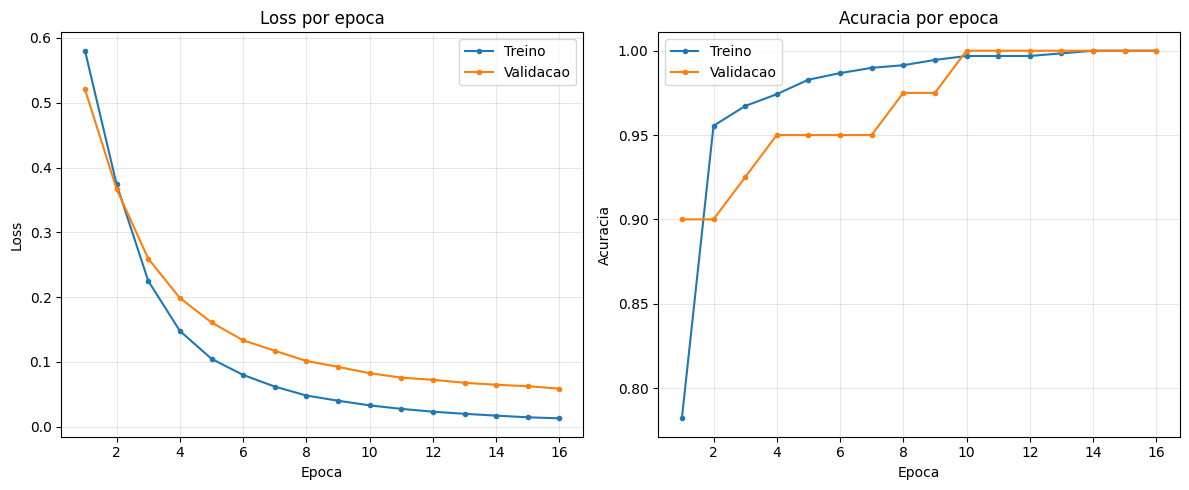

In [19]:
# plotagem do historico de treinamento
if "history_df" not in globals() or history_df.empty:
    print("history_df vazio ou nao definido. Execute o treino ou carregue o checkpoint.")
else:
    epochs = history_df["epoch"]

    plt.figure(figsize=(12, 5))

    # loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["train_loss"], label="Treino", marker="o", markersize=3)
    plt.plot(epochs, history_df["val_loss"], label="Validacao", marker="o", markersize=3)
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.title("Loss por epoca")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # acuracia
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["train_acc"], label="Treino", marker="o", markersize=3)
    plt.plot(epochs, history_df["val_acc"], label="Validacao", marker="o", markersize=3)
    plt.xlabel("Epoca")
    plt.ylabel("Acuracia")
    plt.title("Acuracia por epoca")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



O grafico de evolução da loss de treinamento não apresenta características associadas a underfitting ou overfitting, apesar da acurácia de treinamento ter chegado a 100%. Isso ocorreu devido ao cuidado na curadoria das imagens e no ajuste da cabeça de classificação, aumentando a capacidade de representação do modelo através de uma cabeça ligeiramente mais sofisticada, onde substiuimos uma camada linear por duas camadas, 256 -> Relu() -> Dropout() -> Classificacao. Vamos comprovar posteriormente com um conjunto de teste independente para avaliar o desempenho do modelo.

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [20]:
val_loss, val_acc, val_labels, val_preds = evaluate(
    model=model,
    val_loader=val_loader,
    criterion=criterion,
    device=device
)

print("Val accuracy:", val_acc)

print(confusion_matrix(val_labels, val_preds))

print(classification_report(
    val_labels,
    val_preds,
    target_names=val_dataset.classes
))

Val:   0%|          | 0/2 [00:00<?, ?it/s]

Val accuracy: 1.0
[[20  0]
 [ 0 20]]
              precision    recall  f1-score   support

      abelha       1.00      1.00      1.00        20
       vespa       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



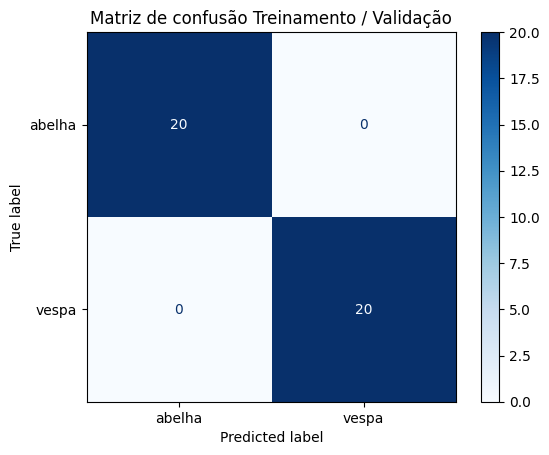

In [21]:
ConfusionMatrixDisplay.from_predictions(
    val_labels,
    val_preds,
    display_labels=val_dataset.classes,
    cmap="Blues",
)
plt.title("Matriz de confusão Treinamento / Validação")
plt.show()

A seguir exibimos as imagens classificadas incorretamente, caso existam. Isso nos permite revisar a curadoria das imagens, identificando se uma imagem precisa ser substituida ou se o modelo precisa ser reforçado. Em nossa execução, observamos que algumas imagens geradas por IA encontradas nas buscas geravam mais confusão ao modelo. Também identificamos a necessidade de reforçar a cabeça de classificação, trocando um modelo linear por um modelo com duas camadas, 256 nós -> Relu(9 -> Dropout -> 2 nós). Com isso obtivemos um modelo com 100% de acurácia no treinamento/validação.

Posteriomente vamos testar o modelo contra um novo dataset obtido por outro buscador, e garantindo que não existem imagens repetidas no conjunto de teste.

In [22]:
wrong_predictions = []

model.eval()

with torch.no_grad():
    for i in range(len(val_dataset)):
        image_tensor, label = val_dataset[i]

        image_tensor = image_tensor.unsqueeze(0).to(device)

        output = model(image_tensor)
        pred = output.argmax(dim=1).item()

        if pred != label:
            image_path, _ = val_dataset.samples[i]

            wrong_predictions.append({
                "index": i,
                "image_path": image_path,
                "real_label": val_dataset.classes[label],
                "pred_label": val_dataset.classes[pred],
            })

wrong_predictions

[]

In [23]:
if not wrong_predictions:
    print("Não existem imagens com previsão equivocada")
else:
    for wrong in wrong_predictions:
        image = Image.open(wrong["image_path"]).convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Real: {wrong['real_label']} | Predito: {wrong['pred_label']}\n"
            f"{wrong['image_path'].name}"
        )
        plt.show()

Não existem imagens com previsão equivocada


Agora que já treinamos o modelo com sucesso, vamos salvar o checkpoint para evitar rodar o treinamento completo novamente.

In [24]:
# utiliza globals() se por acaso a celula que define trained_this_run nao foi executada
if globals().get("trained_this_run", False):
    save_insetos_checkpoint(
        model,
        train_dataset,
        history_df,
        best_val_acc,
        CHECKPOINT_PATH,
    )
else:
    print(
        "Treino não executado nesta sessão; "
        f"checkpoint existente mantido em {CHECKPOINT_PATH}."
    )

Treino não executado nesta sessão; checkpoint existente mantido em checkpoints/insetos_resnet50_best.pt.


E salvamos também o historico de evolução de loss e acurácia do treinamento.

In [25]:
if "history_df" not in globals():
    print("Execute a celula 33 de treino antes desta celula (history_df nao definido).")
elif history_df.empty:
    if HISTORY_CSV_PATH.exists():
        print(f"Historico existente mantido em: {HISTORY_CSV_PATH.resolve()}")
    else:
        print(
            "history_df vazio. Execute a celula 33 de treino para "
            "carregar ou gerar o historico."
        )
# utiliza globals() se por acaso a celula que define trained_this_run nao foi executada        
elif globals().get("trained_this_run", False):
    HISTORY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print(f"Historico salvo em: {HISTORY_CSV_PATH.resolve()}")
elif HISTORY_CSV_PATH.exists():
    print(f"Historico existente mantido em: {HISTORY_CSV_PATH.resolve()}")


Historico existente mantido em: /Users/gilcesarf/git/repositories/imd/imd1114-202601/deep-learning/checkpoints/insetos_training_history.csv


Agora vamos preparar a inferencia a partir de um novo dataset obtido a partir de outra fonte de busca. Escolhemos o Baidu pois o Google Crawler não está funcionando na nossa versão.

In [26]:
'''
Preparacao para inferencia com suporte a execucao parcial do notebook.

Celulas obrigatorias antes desta (kernel reiniciado, inferencia Baidu com checkpoint):
    - imports, device, config (paths) e funcoes utilitarias (celula 9/10)
    - definicao do modelo: carrega checkpoint e define model, class_to_idx,
      idx_to_class, history_df (nao pule esta celula)

Celulas que podem ser omitidas neste fluxo:
    - datasets/loaders (celula 18) — treino e validacao em val
    - treino (celula 32) — no-op quando model_loaded_from_checkpoint e True

Por que recriar preprocess aqui:
    O checkpoint nao persiste o pipeline de transformacao. predict_image e a
    inferencia Baidu abaixo precisam do mesmo preprocess do treino (Resize,
    ToTensor, normalizacao ImageNet). Recriamos via ResNet50_Weights.DEFAULT
    para nao depender da celula 18.
'''
preprocess = models.ResNet50_Weights.DEFAULT.transforms()


In [27]:
def predict_image(image_path, model, preprocess, idx_to_class, device):
    '''
    Classifica uma unica imagem e retorna rotulo predito e probabilidades.

    Abre a imagem em RGB, aplica preprocess (mesmo pipeline do treino),
    executa forward pass sem gradientes e converte logits em classe e softmax.

    Parametros
    ----------
    image_path : str | Path
        Caminho do arquivo de imagem.
    model : torch.nn.Module
        Modelo treinado em modo eval (ex.: ResNet50 com fc adaptada).
    preprocess : Callable
        Transformacao torchvision (ex.: weights.transforms() do ResNet50).
    idx_to_class : dict[int, str]
        Mapeamento indice numerico -> nome da classe.
    device : torch.device
        Dispositivo onde o modelo esta alocado.

    Retorna
    -------
    tuple[str, numpy.ndarray]
        pred_label: nome da classe com maior probabilidade.
        probs: array shape (1, num_classes) com softmax dos logits.
    '''
    with Image.open(image_path) as img:
        img = img.convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = logits.argmax(dim=1).item()
    return idx_to_class[pred_idx], torch.softmax(logits, dim=1).cpu().numpy()

Nossa busca com o Baidu exigiu traduzir os termos de busca para o chines, pois o buscador do Baidu não funciona muito bem com termos em inglês. O tratamento para evitar imagens duplicadas na busca, bem como evitar duplicados em relação ao conjunto de treinamento/validação foi aplicado novamente.

In [28]:
# Segunda fonte (Baidu): so baixa o que faltar; remove duplicatas vs dataset Bing
search_terms_alt = {
    "abelha": "蜜蜂 自然 实拍 昆虫",
    "vespa": "黄蜂 自然 实拍 昆虫",
}
## Os termos acima corresponde a seguinte busca em português:
##search_terms_alt = {
##    "abelha": "Abelha, Natureza, Foto Real, Inseto",
##    "vespa": "Vespa, Natureza, Foto Real, Inseto",
##}
##
for label, term in search_terms_alt.items():
    baidu_image_crawler = BaiduImageCrawler(storage={"root_dir": "images"})
    download_images(
        baidu_image_crawler,
        term,
        BAIDU_ROOT / label,
        # n_total=N_IMAGES_PER_CLASS,
        n_total=20,
        reference_dirs=REFERENCE_DIRS,
        duplicate_threshold=DUPLICATE_THRESHOLD,
    )

if BAIDU_ROOT.exists():
    print(f"Removendo duplicatas do Baidu em relacao a {REFERENCE_DIRS}...")
    removed = remove_duplicates_against_reference(
        BAIDU_ROOT,
        REFERENCE_DIRS,
        threshold=DUPLICATE_THRESHOLD,
    )
    print(f"Total removidas em {BAIDU_ROOT}: {removed}")
else:
    print(f"{BAIDU_ROOT} ainda nao existe; pulando limpeza de duplicatas.")


Pasta já possui 20 imagens. Nenhum download necessário para alvo n_total=20.
Pasta já possui 20 imagens. Nenhum download necessário para alvo n_total=20.
Removendo duplicatas do Baidu em relacao a [PosixPath('data/insetos')]...
abelha: removidas=0, restantes=20
vespa: removidas=0, restantes=20
Total removidas em data/insetos-baidu: 0


In [29]:
# Segunda passada pos-download: garante que nenhuma imagem Baidu repete o Bing
if not BAIDU_ROOT.exists():
    print(f"{BAIDU_ROOT} nao existe; pulando limpeza de duplicatas.")
else:
    print(f"Removendo duplicatas do Baidu vs referencia {REFERENCE_DIRS}...")
    removed_total = remove_duplicates_against_reference(
        BAIDU_ROOT,
        REFERENCE_DIRS,
        threshold=DUPLICATE_THRESHOLD,
    )
    print(f"Total removidas em insetos-baidu: {removed_total}")


Removendo duplicatas do Baidu vs referencia [PosixPath('data/insetos')]...
abelha: removidas=0, restantes=20
vespa: removidas=0, restantes=20
Total removidas em insetos-baidu: 0


## Inferencia com Dataset de Teste (Baidu)

In [30]:
# Inferencia com novas imagens (Baidu)
baidu_labels = []
baidu_preds = []
baidu_samples = []

class_names = sorted(class_to_idx.keys())

model.eval()

if not BAIDU_ROOT.exists():
    print(f"{BAIDU_ROOT} nao existe; pulando inferencia Baidu.")
else:
    with torch.no_grad():
        for class_dir in sorted(BAIDU_ROOT.iterdir()):
            if not class_dir.is_dir():
                continue

            if class_dir.name not in class_to_idx:
                print(f"Classe desconhecida ignorada: {class_dir.name}")
                continue

            true_idx = class_to_idx[class_dir.name]

            for image_path in list_images(class_dir):
                pred_label, _ = predict_image(
                    image_path, model, preprocess, idx_to_class, device
                )
                pred_idx = class_to_idx[pred_label]

                baidu_labels.append(true_idx)
                baidu_preds.append(pred_idx)
                baidu_samples.append((true_idx, pred_idx, image_path))

if len(baidu_labels) == 0:
    print("Nenhuma imagem Baidu encontrada para avaliacao.")
else:
    baidu_acc = sum(
        label == pred for label, pred in zip(baidu_labels, baidu_preds)
    ) / len(baidu_labels)

    print(f"Imagens Baidu avaliadas: {len(baidu_labels)}")
    print("Baidu accuracy:", baidu_acc)

    print(confusion_matrix(baidu_labels, baidu_preds))

    print(classification_report(
        baidu_labels,
        baidu_preds,
        target_names=class_names,
    ))


Imagens Baidu avaliadas: 40
Baidu accuracy: 0.975
[[20  0]
 [ 1 19]]
              precision    recall  f1-score   support

      abelha       0.95      1.00      0.98        20
       vespa       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



### Imagens classificadas equivocadamente


Erros Baidu: 1


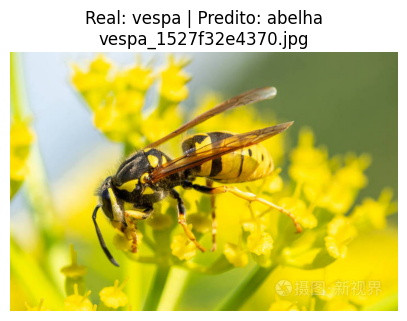

In [31]:
if len(baidu_labels) == 0:
    print("Nenhuma imagem Baidu encontrada para avaliacao.")
else:
    baidu_wrong_predictions = []
    for true_idx, pred_idx, image_path in baidu_samples:
        if true_idx == pred_idx:
            continue

        baidu_wrong_predictions.append({
            "image_path": image_path,
            "real_label": idx_to_class[true_idx],
            "pred_label": idx_to_class[pred_idx],
        })

    print(f"\nErros Baidu: {len(baidu_wrong_predictions)}")

    for wrong in baidu_wrong_predictions:
        image = Image.open(wrong["image_path"]).convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Real: {wrong['real_label']} | Predito: {wrong['pred_label']}\n"
            f"{wrong['image_path'].name}"
        )
        plt.show()


### Matriz de Confusão

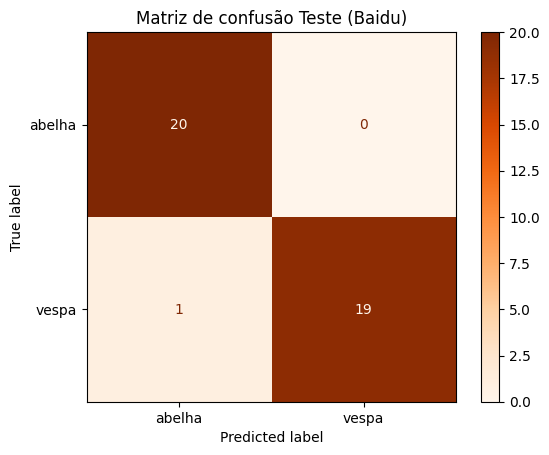

In [32]:
ConfusionMatrixDisplay.from_predictions(
    baidu_labels,
    baidu_preds,
    display_labels=class_names,
    cmap="Oranges",
)
plt.title("Matriz de confusão Teste (Baidu)")
plt.show()

O teste do modelo mostrou acurácia de 97% com um novo conjunto de dados obtido a partir de uma fonte independente. Isso mostra que o desempenho do modelo foi muito bom, e que a transferencia de conhecimento ocorreu de forma adequada e sem gerar overfitting.

De 40 imagens (20 abelhas e 20 vespas) do conjunto de teste, apenas 1 imagem foi classificada equivocadamente. A imagem de uma vespa foi predita como abelha (exibida anteriormente). Podemos observar que a imagem em questão possui um desfocamento do fundo, que pode gerar confusão com as caracteristicas de pelos associado a abelhas e não a vespas. Além disso, o fundo onde aparece a vespa é predominantemente amarelo, o que geralmente está associado a abelhas. 

Para corrigir isso poderiamos adicionar mais imagens ao treinamento onde as abelhas não aparecem em fundos amarelos, adicionar mais imagens com vespas em fundo amarelo, ou ainda reprogramar o data augmentation para incluir exemplos de abelhas sem o fundo predominante amarelo e vespas com fundo amarelo, para forçar o modelo a não aprender a partir do fundo. Talvez até incluir imagens em tons de cinza pudesse ajudar aqui.